# Tests

Some preliminary tests (last updated by Pierre)

## 1 Preliminaries <a id='preliminaries'></a>
### 1.1 Packages <a id='packages'></a>
[Back to content](#content)

In [5]:
# Load packages, including CAMB
%matplotlib inline
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pickle
# Use TeX
from matplotlib import rc
import inspect
from scipy.integrate import quad
from scipy.optimize import root_scalar, minimize_scalar

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

# Path to save figures
path = 'Figures/'

## 1.3 loading correlations and distributions

In [37]:
global_dict = {}

def load_correlations(filename="correlations"):
    """Loads a pickled dictionary from 'filename' and adds its contents to global_dict."""
    try:
        with open(filename, "rb") as f:
            data = pickle.load(f)  # Load the dictionary from the pickle file
    except FileNotFoundError:
        raise FileNotFoundError(f"File '{filename}' not found.")
    except pickle.UnpicklingError:
        raise ValueError(f"File '{filename}' is not a valid pickle file.")

    if isinstance(data, dict):
        global_dict.update(data)  # Merge the loaded dictionary into global_dict
    else:
        raise ValueError("The pickled file does not contain a dictionary.")

def arcmintorad(angle_arcmin):
    """
    This function converts an an angle expressed in arcmins
    into radians.
    """
    
    angle_rad = angle_arcmin / (60 * 180 / np.pi)
    
    return angle_rad

def get_item(*names):
    """Retrieves items from global_dict and defines them as global variables in the caller's module."""
    frame = inspect.currentframe().f_back  # Get caller's frame
    caller_globals = frame.f_globals  # Access the caller's global namespace
    
    for name in names:
        if name in global_dict:
            caller_globals[name] = global_dict[name]  # Define the variable globally
        else:
            raise KeyError(f"'{name}' not found in global_dict")

def load_file(filename):
    """Loads a pickled dictionary"""
    with open(filename, "rb") as f:
        data = pickle.load(f)  # Load the dictionary from the pickle file

def find_maximum(f, a, b):
    result = minimize_scalar(lambda x: -f(x), bounds=(a, b), method='bounded')
    if result.success:
        x_max = result.x
        f_max = f(x_max)
        return x_max, f_max
    else:
        raise RuntimeError("Failed to find maximum.")

In [80]:
Nbin_z = 1
load_correlations(filename=f"correlations_NE={Nbin_z}_NP={Nbin_z}")
sigma_L = 0.05
Nlens = 1e5
L0 = 0.05**2

sigma_E = np.sqrt(2) * 0.3  
NGal = 2e9              #total number of galaxies (expect 2e9)
sky_coverage = 15e3     #area of sky covered by the survey (deg^2)
nTheta = 100000
Thetamax_dist = 3e2     #maximum theta to calculate distributions inputted into covariance matrices (arcmin)
zmax_dist = 3
Omegatot = sky_coverage * (np.pi / 180)**2 # in sqrad

## 3. Plotting integrated correlation functions (testing optimised binscheme)

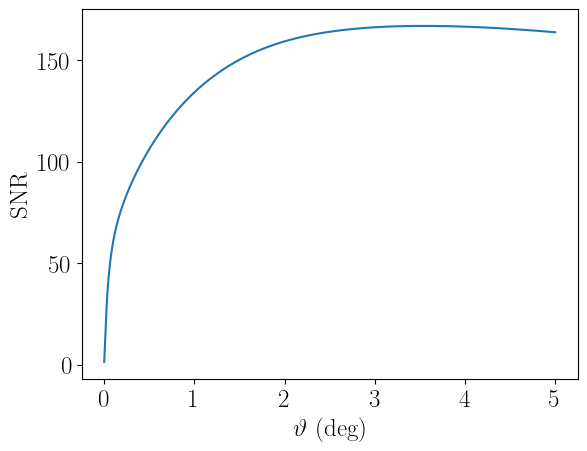

In [69]:
get_item('LL_plus', 'LL_minus')
get_item('LLp', 'LLx', 'LP', 'PP')
# print(global_dict)

def integral_bins(correlation_function, Theta_start, Theta_end):

    def integrand(x):
        return 2 * np.pi * x * correlation_function(x)
    
    integral, err = quad(integrand, Theta_start, Theta_end)

    return integral


def signal(integrand, theta):
    
    Omega = np.pi * theta**2 
    integral = integral_bins(integrand, 0, theta)

    return integral/Omega


Thetamin_arcmin = 0.1 
Thetamax_arcmin = 300

Thetamin = arcmintorad(Thetamin_arcmin)
Thetamax = arcmintorad(Thetamax_arcmin)

logThetamin = np.log10(Thetamin)
logThetamax = np.log10(Thetamax)
Theta = np.logspace(logThetamin, logThetamax, 200)

Theta_deg = Theta * 180/np.pi

snr = []
noises = []

for theta_val in Theta:
    
    s = signal(LP[0], theta_val)
    
    Omegabin = np.pi * theta_val**2 # in sqrad
    noise = np.sqrt((sigma_L**2 + L0) / Nlens / NGal * Omegatot / Omegabin / 2)
    
    noises.append(noise)
    snr.append(s / noise)

plt.plot(Theta_deg, snr)
plt.ylabel(r'SNR')
plt.xlabel(r'$\vartheta$ (deg)');

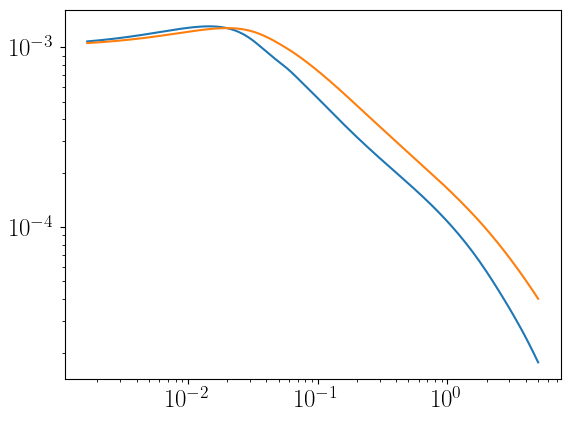

In [70]:
plt.loglog(Theta_deg, LP[0](Theta))
s = [signal(LP[0], th) for th in Theta]
plt.loglog(Theta_deg, s)

In [67]:
i_max = np.argmax(snr)
theta_max = Theta[i_max]
s_max = signal(LP[0], theta_max)
M1 = snr[i_max]
print('theta_max = {} rad'.format(theta_max))
print('theta_max = {} arcmin'.format(theta_max * 180 / np.pi * 60))
print('signal for optimal bin = {}'.format(s_max))
print('max SNR = ', M1)

theta_max = 0.06075620401455718 rad
theta_max = 208.8644441561949 arcmin
signal for optimal bin = 5.858971398287316e-05
max SNR =  166.9701887347189


In [15]:
SNR_goal = 8
Nbin_max = 20          #this should dictate the maximum number of angular bins, but it won't be exact, and relies on an empirical relationship
SNR_min = 2.5
theta_resolution = 1000  #the number of thetas in the linspace with which we obtain the max theta and calculate the "total SNR"

SNR_goal_LL_plus = 6
Nbin_max_LL_plus =  Nbin_max
SNR_min_LL_plus = SNR_min 

SNR_goal_LL_minus = 6
Nbin_max_LL_minus =  Nbin_max
SNR_min_LL_minus = SNR_min

SNR_goal_EE_plus = SNR_goal
Nbin_max_EE_plus =  Nbin_max
SNR_min_EE_plus = SNR_min 

SNR_goal_EE_minus = SNR_goal
Nbin_max_EE_minus =  Nbin_max
SNR_min_EE_minus = SNR_min    

SNR_goal_PP = SNR_goal
Nbin_max_PP =  Nbin_max
SNR_min_PP = SNR_min      

SNR_goal_LE_plus = SNR_goal
Nbin_max_LE_plus =  Nbin_max
SNR_min_LE_plus = SNR_min   

SNR_goal_LE_minus = SNR_goal
Nbin_max_LE_minus =  Nbin_max
SNR_min_LE_minus = SNR_min       

SNR_goal_LP = SNR_goal
Nbin_max_LP =  Nbin_max
SNR_min_LP = SNR_min      

SNR_goal_EP = SNR_goal
Nbin_max_EP =  Nbin_max
SNR_min_EP = SNR_min  

In [15]:

def redshift_distribution_Euclid(z):
    """
    This is the total redshift distribution of galaxies
    expected from the Euclid survey.
    Source: eq. (10) of https://arxiv.org/pdf/2010.07376.pdf
    """
    
    a = 0.4710
    b = 5.1843
    c = 0.7259
    A = 1.75564 # ensures normalisation to 1
    
    n = A * (z**a + z**(a*b)) / (z**b + c)
    
    return n
    
class Redshift_Distributions:
    """
    This class produces anything useful related to the redshift binning of galaxies
    """
    
    def __init__(self, Nobjects, binscheme, Nbinz = Nbin_z, zmax_dist = zmax_dist, starting_distribution = redshift_distribution_Euclid):
        """
        Arguments:
        - Nobjects      : number of objects we can use
        - binscheme     : list, min and max redshifts of each redshift bin (if None, bins are equally populated)
        - Nbinz         : number of bins of redshift
        - zmax_dist     : maximum redshift (expect 3)
        
        All the angular attributes will be expressed in rad.
        """

        self.Nobjects = Nobjects
        self.Nbinz = Nbinz
        self.zmax_dist = zmax_dist
        
        self.starting_distribution = starting_distribution
        self.binscheme = binscheme

        total, _ = quad(starting_distribution, 0, self.zmax_dist)    #the total value of the distribution (needed for the normalisation)
        self.norm_factor = total

        # Binning
        if isinstance(binscheme, int) or binscheme is None:
    
            # Find redshift values that divide the CDF into Nbinz equal parts
            
            bin_edges = [0.0]   #initialise the list of bin edges with 0
            
            for i in range(1, Nbinz):    
                target = i / Nbinz      #we want the target cumulative distribution to be i / Nbinz of the total  
                sol = root_scalar(lambda z: self.cdf(z) - target, bracket=[0, self.zmax_dist], method='brentq')  #looking for the solution z to the equation cdf(z) - target = 0, within [0, zmax]
                bin_edges.append(sol.root) #whatever that solution is gets appended as the new bin edge
                
            bin_edges.append(zmax_dist) #we then close the last bin
    
            self.limits = np.array(bin_edges)

        elif isinstance(binscheme, (list, np.ndarray)):
            self.limits = np.array(binscheme)  
            
        else:
            raise ValueError("Invalid binscheme: must be None, int, or array-like.")      


    def overall_distribution(self, z):

        return self.starting_distribution(z) / self.norm_factor
    
    def cdf(self, z):
        """
        A cumulative distribution function
        """
        
        result, _ = quad(self.overall_distribution, 0, z)
        
        return result
        
    def pb(self, z, b):
        """
        This is the redshift distribution of galaxies for each redshift bin, normalised for that bin.
    
        z  : the redshift
        b  : the redshift bin (0 to Nbin_z)
        """
        
        zzmin = self.limits[b]
        zzmax = self.limits[b + 1]

        if zzmin <= z < zzmax:
            normalisation_factor, _ = quad(self.overall_distribution, zzmin, zzmax) #the integral of the distribution in that bin
            distrib = self.overall_distribution(z) / normalisation_factor #renormalising for that bin
            
        else:
            distrib = 0
        
        return distrib

    
    def find_bin(self, z):
        """
        This function finds the redshift bin to which a galaxy at redshift z would belong
        """
        for i in range(self.Nbinz):
            if self.limits[i] <= z < self.limits[i + 1]:
                return i
        print('Warning: redshift out of bin range')
        return None

    def get_ngal(self, b):
            """
            Returns the number of galaxies in redshift bin `b`.
    
            b : index of the redshift bin (0 to Nbinz)
            """
            zzmin = self.limits[b]
            zzmax = self.limits[b + 1]
    
            result, _ = quad(self.overall_distribution, zzmin, zzmax) #the fraction of the overall distribution between zzmin and zzmax
            
            return result * self.Nobjects

In [16]:
Nbinz_E = Nbin_z
Nbinz_P = Nbin_z
binscheme_E = Nbinz_E
binscheme_P = Nbinz_P
zmax_E = zmax_dist
zmax_P = zmax_dist

redshift_distribution_E = Redshift_Distributions(NGal, binscheme = binscheme_E, Nbinz = Nbinz_E, zmax_dist = zmax_E)
redshift_distribution_P = Redshift_Distributions(NGal, binscheme = binscheme_P, Nbinz = Nbinz_P, zmax_dist = zmax_P)

redshift_distributions = {"E" : redshift_distribution_E,
                          "P" : redshift_distribution_P}

In [18]:
notes = '' #anything particularly unique about a particular run (eg different redshift binning)
correlation_notes = ''    #needed only to specify that a particular binscheme has been used

def format_sci(n):
    return f'{n:.0e}'.replace('+00', '').replace('+0', '').replace('+', '').replace('-0', '-')

# suffix = f'Nlens={format_sci(Nlens)}_sigL={sigma_L}_Nbin_z={Nbin_z}_SNR_goal={SNR_goal}_Nbin_max={Nbin_max}_nsamp={nsamp_string}{notes}'

In [19]:
get_item('LL_plus', 'LL_plus_primitive', 'LL_minus', 'LL_minus_primitive', 'LE_plus', 'LE_plus_primitive', 'LE_minus', 'LE_minus_primitive', 'LP', 'LP_primitive')

def print_optimise_bins(correlation_function, correlation_type, antiderivative, b, SNR_goal = 20, Nbin_max = 10, SNR_min = 1.5, Thetamax_distribution = Thetamax_dist):

    Thetamax_distribution = arcmintorad(Thetamax_distribution)
    
    get_item('L0', 'E0') #we'll need these for the prefactors in the signal to noise ratios

    if correlation_type == 'LE':
        G_B = redshift_distributions['E'].get_ngal(b)

    elif correlation_type == 'LP':
        G_B = redshift_distributions['P'].get_ngal(b)
    
    def snr(theta_1, theta_2):

        numerator = np.abs(antiderivative(theta_2) - antiderivative(theta_1))
        denom_sq = theta_2**2 - theta_1**2
        
        if denom_sq <= 0:
            return 0

        denominator = np.sqrt(denom_sq)
        
        if correlation_type == 'LL':
            A = 2 * np.sqrt(np.pi / Omegatot) * Nlens / (sigma_L**2 + L0)
        
        elif correlation_type == 'LE': #check the factors of 2
            A = 2 * np.sqrt(np.pi / Omegatot) * np.sqrt( 2 * Nlens * G_B / ( (sigma_L**2 + L0) * (sigma_E**2 + E0[b]) ) )
        
        elif correlation_type == 'LP': #check the factors of 2
            A = 2 * np.sqrt(np.pi / Omegatot) * np.sqrt( 2 * Nlens * G_B / (sigma_L**2 + L0) )
        
        return A * numerator / denominator

    def SNR(theta):
        return snr(0,theta)
        
    theta_optimal, SNR_max = find_maximum(SNR, 0, Thetamax_distribution)

    print("M1 = ", SNR_max)

    if SNR_max < SNR_goal:               #if our goal SNR is unachievable, even with just 1 bin
        return [0, theta_optimal]         #return a single bin (the best we can do)

    #if the above isn't satisfied, then it means that SNR_goal < SNR_max. This means that 
    
    else: #if our goal SNR is in fact achievable, we want to iteratively determine our bins
        
        #the SNR we use is either our goal SNR or the SNR limited by the max number of bins we want
        SNR_use = max(SNR_goal, SNR_max / ( np.sqrt( 0.5 * Nbin_max ) ) )    #NB this is not exact, and purely empirical
        print("R = ", SNR_use)

        binscheme = [0] #our bins start at zero    

        alpha = 0
        
        finished = False
        
        while not finished:
            
            def SNR_to_optimise(theta):
                """
                A function which goes to zero when the integrated snr between the bin limit on the left and some theta value is equal to the SNR we want to use. 
                To get to this point, we must have already passed the test that SNR_goal < SNR_max. Therefore, both SNR_goal and SNR_max / Nbin_max exist within
                the range [ binscheme[alpha], theta_optimal ], and therefore so too must their maximum, so this function will always have an x-intercept.

                Note that, for this method to work, the snr should increase monotonically up to the maximum, but it seems that this is indeed the case (check for issues!)
                """
                
                return snr(binscheme[alpha], theta) - SNR_use
   
            theta_new = root_scalar(SNR_to_optimise, bracket=[binscheme[alpha], theta_optimal], method='brentq', xtol=1e-8).root #this solves for the value of theta which gets us to our desired snr

            alpha += 1
            binscheme.append(theta_new)

            #once we've found the new bin limit, we must once again define a function which returns the SNR from that bin limit to some arbitrary theta  
            def SNR(theta):
                return snr(binscheme[alpha],theta)

            #we then want to find what the maximum SNR beyond this point is
            theta_optimal, SNR_max = find_maximum(SNR, theta_new, Thetamax_distribution)

            #if our goal SNR is unachievable with the remaining binning 
            if SNR_max < SNR_use:     

                #if, however, the SNR is still acceptable,
                if SNR_max >= SNR_min:

                    #the optimal theta becomes the final bin limit
                    binscheme.append(theta_optimal)

                #if the SNR in the last bin would be unusable,
                else:

                    #we need a function which returns the SNR from the previous bin limit (before the most recently added one) to some arbitrary theta
                    def SNR(theta):
                        return snr(binscheme[-2],theta)

                    #this maximum might occur at the most recent bin limit, or at a higher value of theta
                    theta_optimal_new, SNR_max_new = find_maximum(SNR, binscheme[-2], Thetamax_distribution)

                    #either way, the theta we obtain in the above becomes our new final bin limit
                    binscheme[-1] = theta_optimal_new

                #either way, provided SNR_max < SNR_use, our while loop is done
                finished = True

        return binscheme       

zbin = 0

binscheme = print_optimise_bins(LP[zbin], 'LP', LP_primitive[zbin], b = zbin, SNR_goal = SNR_goal_LP, Nbin_max = Nbin_max_LP, SNR_min = SNR_min_LP)

print("Nbins = ", len(binscheme)-1)

M1 =  159.10671979840058
R =  50.31396256011521
Nbins =  18


# Testing the covariance

In [17]:
def monte_carlo_integrate(funcs, bounds, num_samples=1e4, num_batches=1):
    """
    Monte Carlo integration over a given domain with error estimation.
    
    Parameters:
    - funcs (callable or list of callables): The function to integrate. NB it needs to accept an array as input
                       for integration over multiple dimensions.
    - bounds (list of tuples): Integration bounds [(a1, b1), (a2, b2), ...].
                                For 1D, use [(a, b)].
    - num_samples (int): Total number of random samples to be used in the integration
    - num_batches: The number of batches into which our samples are split, to reduce the memory burden
    
    Returns:
    - tuple: (float, float) Estimated value of the integral and its error (or a list of tuples if multiple functions inputted)
    """

    #our function is defined to handle multiple integrands evaluated with the same sample of points. 
    #if a single function is provided, we redefine it as a single-item list
    if not isinstance(funcs, (list, tuple)):
        funcs = [funcs]
        single_function = True
    else:
        single_function = False
    
    nsamp_use = int(num_samples) #the total number of samples in the integration
    batch_size = nsamp_use // num_batches #the number of samples per batch (to reduce the memory burden)
    dim = len(bounds) #the dimensions of the integral
    volumes = [b - a for a, b in bounds] #the volume over which each variable in the integral is evaluated
    total_volume = np.prod(volumes) #the total volume spanned by the integration bounds
    rng = np.random.default_rng() #defining a random number generator

    #define lists of lists, with as many lists as we have functions
    batch_sums = [ [] for _ in funcs ]     # will store the sums of f from each batch
    batch_sumsq = [ [] for _ in funcs ]    # will store the sums of f**2 from each batch

    batch_ns = []                          # will store the number of samples per batch
    #as currently written, every element in batch_ns will simply be equal to batch_size

    #compute rescale values once at the start for each function (for numerical stability)
    n_subsample = 100
    subsamples = np.array([rng.uniform(low=a, high=b, size=n_subsample) for a, b in bounds])
    rescale_vals = []
    for func in funcs:
        f_subsample = func(subsamples)
        typical_scale = np.median(np.abs(f_subsample))
        if typical_scale == 0:
            rescale_vals.append(1.0)  # function is zero, no rescaling needed
        else:
            rescale_vals.append(1.0 / typical_scale)

    #proceed batch by batch
    for _ in range(num_batches):

        #draw a random sample of N points on the integration domain (n=batch_size)
        samples = np.array([rng.uniform(low=a, high=b, size=batch_size) for a, b in bounds])

        #proceed one function at a time
        for i, func in enumerate(funcs):

            values = func(samples) * rescale_vals[i]  #evaluate the function at each of the N sampled points

            batch_sums[i].append(np.sum(values)) #store the sum of each of the n function outputs
            batch_sumsq[i].append(np.sum(values**2)) #store the sum of the square of these outputs
        batch_ns.append(values.size)   #store n (should always be batch_size with the current structure)

    final_integrals = [] #will store the final estimated integrals for each function
    errors = [] #will store the errors in those estimates

    for i in range(len(funcs)):
        N = int(np.sum(batch_ns))                        # total number of samples (might be less than nsamp, depending on the batching)
        total_sum = float(np.sum(batch_sums[i]))         # sum of f over all samples
        total_sumsq = float(np.sum(batch_sumsq[i]))      # sum of f^2 over all samples

        mean_f = total_sum / N #the mean of the function across all points

        if N > 1:
            # sample variance
            var_f = (total_sumsq - N * mean_f**2) / (N - 1) #the sample variance
            var_f = max(var_f, 0.0) #in case of numerical errors leading to negative values
        else:
            var_f = 0.0 #no variance if we've just evaluated at a single point

        mean_integral = total_volume * mean_f #the monte carlo integral estimate for this function
        std_error = total_volume * np.sqrt(var_f / N) #the error in the monte carlo integral for this function

        final_integrals.append(mean_integral/rescale_vals[i])
        errors.append(std_error/rescale_vals[i])

    if single_function:
        return final_integrals[0], errors[0]
        
    else:
        return final_integrals, errors


def test_err(error, signal, name):

    if signal != 0:
        if np.abs(error/signal) > total_error_threshold:
            print(f"Warning! Total error for {name} is {round(np.abs(error/signal),1)}") 

In [71]:
cos2 = lambda x: np.cos(2*x)
sin2 = lambda x: np.sin(2*x)

def generate_ncov_LPLP(sigma_L, Nlens, B, D, theta, include_diagonal_term=True):
    """
    Computes the contribution of noise and sparsity variance in the 
    covariance matrix of the LOS shear - galaxy position correlation functions.
    
    B             : the galaxy redshift bin B  (0 to 4)
    D             : the galaxy redshift bin D (0 to 4)
    """
    
    #angular_distribution1 = angular_distributions['LP'][B]
    #angular_distribution2 = angular_distributions['LP'][D]
    
    #Nbin1       = angular_distribution1.Nbina      #the number of angular bins
    Nbin1   = 1
    #Omegas1     = angular_distribution1.Omegas     #\Omega_a in the math - the solid angle of bin a (in rad^2)
    Omegas1 = [np.pi * theta**2]
    #rs1         = angular_distribution1.limits     #the angular bin limits (in rad)
    rs1 = [0, theta]
    
    #Nbin2       = angular_distribution2.Nbina      #the number of angular bins
    Nbin2   = 1
    #Omegas2     = angular_distribution2.Omegas     #\Omega_a in the math - the solid angle of bin a (in rad^2)
    Omegas2 = [np.pi * theta**2]
    #rs2         = angular_distribution2.limits     #the angular bin limits (in rad)
    rs2 = [0, theta]
    
    
    redshift_distribution = redshift_distributions['P']

    G_B    = redshift_distribution.get_ngal(B)         #G_B in the math - the number of galaxies in redshift bin B
    
    # Initialise the blocks
    ncov = np.zeros((Nbin1, Nbin2))
    scov = np.zeros((Nbin1, Nbin2))
    
    nerr = np.zeros((Nbin1, Nbin2))
    serr = np.zeros((Nbin1, Nbin2))
    
    # Define the integrands
    
    def integrand_P(params):
        
        r_i, r_k, psi_k = params
    
        y_ik = r_k*np.sin(psi_k)
        x_ik = r_k*np.cos(psi_k) - r_i
        
        r_ik = np.sqrt( y_ik**2 + x_ik**2 ) 
        psi_ik = np.arctan2(y_ik, x_ik)
        
        f = ( LLp(r_ik) * cos2(psi_ik) * cos2(psi_ik - psi_k) 
                             + LLx(r_ik) * sin2(psi_ik) * sin2(psi_ik - psi_k) )

        f *= 2 * np.pi * r_i * r_k
                              
        return f
    
    def integrand_L(params):
        
        r_i, r_k, psi_k = params
    
        y_ik = r_k*np.sin(psi_k)
        x_ik = r_k*np.cos(psi_k) - r_i
        
        r_ik = np.sqrt( y_ik**2 + x_ik**2 ) 
        psi_ik = np.arctan2(y_ik, x_ik)
        
        f = (1/2) * PP[B][D](r_ik) * cos2(psi_k)

        f *= 2 * np.pi * r_i * r_k
                              
        return f
    
    def integral_bins(integrand, alpha, beta):
        
        ranges = [(rs1[alpha], rs1[alpha+1]), (rs2[beta], rs2[beta+1]), (0, 2*np.pi)]
        
        integral, err = monte_carlo_integrate(integrand, ranges)
        
        # normalisation of differential elements
        integral /= (Omegas1[alpha] * Omegas2[beta]) 
        err     /= (Omegas1[alpha] * Omegas2[beta]) 
        
        return integral, err

    integrand = [integrand_L]

    if B == D:
        integrand.append(integrand_P)
    
    for alpha in range(Nbin1):
        for beta in range(Nbin2): 
                     
            intt, err = integral_bins(integrand, alpha, beta)
                     
            ncov[alpha, beta] = (sigma_L**2/Nlens) * intt[0]     
            nerr[alpha, beta] = (sigma_L**2/Nlens) * err[0]
                     
            scov[alpha, beta] = (L0/Nlens) * intt[0]     
            serr[alpha, beta] = (L0/Nlens) * err[0]

            if B == D:
                ncov[alpha, beta] += (1/G_B) * intt[1]  
                scov[alpha, beta] += (1/G_B) * intt[1]  

                if alpha == beta and include_diagonal_term:
                    ncov[alpha, beta] += (1/2) * (sigma_L**2 / (Nlens*G_B) ) * (Omegatot/Omegas1[alpha])
                    scov[alpha, beta] += (1/2) * (L0 / (Nlens*G_B) ) * (Omegatot/Omegas1[alpha])

            #test_err(nerr[alpha, beta], ncov[alpha, beta], f'LPLP ncov redshifts {B, D} angular bins {alpha, beta}')
            #test_err(serr[alpha, beta], scov[alpha, beta], f'LPLP scov redshifts {B, D} angular bins {alpha, beta}')
            
    # Make the full cosmic covariance matrix

    ncov = np.block([[ncov]])
    scov = np.block([[scov]])

    nerr = np.block([[nerr]])
    serr = np.block([[serr]])
    
    return [ncov, scov], [nerr, serr]

Relative importance of the integral or constant terms

In [72]:
# Noise without the full diagonal term (constant)
[ncov, scov], _ = generate_ncov_LPLP(sigma_L, Nlens, 0, 0, theta_max, include_diagonal_term=False)
noise_full_wo = np.sqrt(ncov[0] + scov[0])
print('sigma_wo_constant = ', noise_full_wo)

# Noise with the full diagonal term (constant)
[ncov, scov], _ = generate_ncov_LPLP(sigma_L, Nlens, 0, 0, theta_max, include_diagonal_term=True)
noise_full_w = np.sqrt(ncov[0] + scov[0])
print('sigma_w_constant = ', noise_full_w)

sigma_wo_constant =  [7.1744829e-06]
sigma_w_constant =  [7.27169258e-06]


In [73]:
theta_test = 0.2 * np.pi / 180 # rad

# Noise without the full diagonal term (constant)
[ncov, scov], _ = generate_ncov_LPLP(sigma_L, Nlens, 0, 0, theta_test, include_diagonal_term=False)
noise_full_wo = np.sqrt(ncov[0] + scov[0])
print('sigma_wo_constant = ', noise_full_wo)

# Noise with the full diagonal term (constant)
[ncov, scov], _ = generate_ncov_LPLP(sigma_L, Nlens, 0, 0, theta_test, include_diagonal_term=True)
noise_full_w = np.sqrt(ncov[0] + scov[0])
print('sigma_w_constant = ', noise_full_w)

TypeError: unsupported operand type(s) for /=: 'list' and 'float'

So the integral term dominates for large angular bins.

In [74]:
def noise_LP(theta):
    
    [ncov, scov], _ = generate_ncov_LPLP(sigma_L, Nlens, 0, 0, theta)
    noise = np.sqrt(ncov[0] + scov[0])
    
    return noise

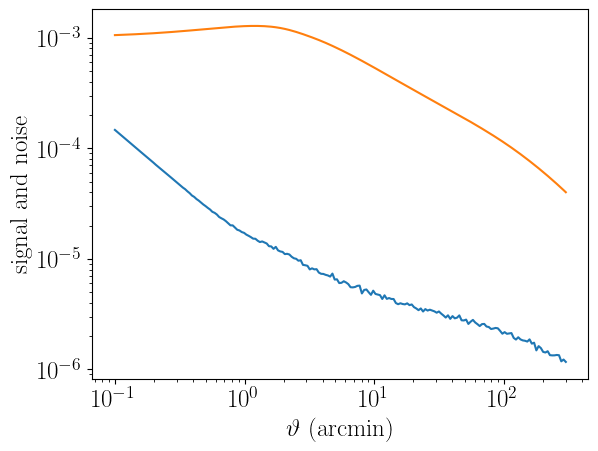

In [81]:
Theta_arcmin = Theta * 180/np.pi * 60
noise = np.array([noise_LP(th) for th in Theta])
sig = np.array([signal(LP[0], th) for th in Theta])
plt.loglog(Theta_arcmin, noise)
plt.loglog(Theta_arcmin, sig)
#plt.loglog(Theta_arcmin, sig/noise)
plt.ylabel(r'signal and noise')
plt.xlabel(r'$\vartheta$ (arcmin)');

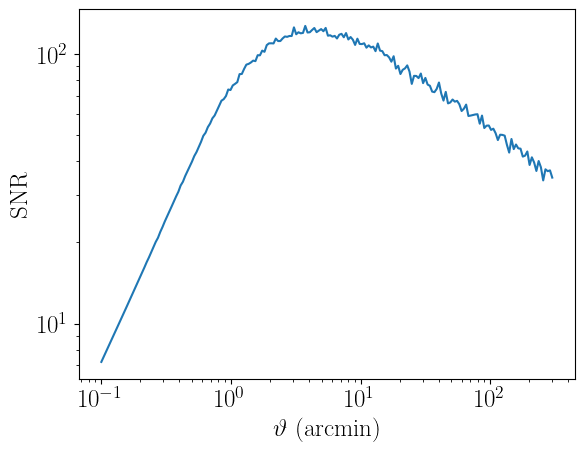

In [82]:
get_item('LL_plus', 'LL_minus')
get_item('LLp', 'LLx', 'LP', 'PP')
# print(global_dict)

def integral_bins(correlation_function, Theta_start, Theta_end):

    integrand = lambda x: 2 * np.pi * x * correlation_function(x)
    
    integral, err = quad(integrand, Theta_start, Theta_end)

    return integral


def signal(integrand, theta):
    
    Omega = np.pi * theta**2 

    integral = integral_bins(integrand, 0, theta)

    return integral/Omega


Thetamin_arcmin = 0.1 
Thetamax_arcmin = 300

Thetamin = arcmintorad(Thetamin_arcmin)
Thetamax = arcmintorad(Thetamax_arcmin)

logThetamin = np.log10(Thetamin)
logThetamax = np.log10(Thetamax)
Theta = np.logspace(logThetamin, logThetamax, 200)

Theta_deg = Theta * 180/np.pi

snr = []
noises = []


for theta_val in Theta:
    
    s = signal(LP[0], theta_val)
    
    Omegabin = np.pi * theta_val**2 # in sqrad
    noise = noise_LP(theta_val)
    
    noises.append(noise)
    snr.append(s / noise)

    
plt.loglog(Theta_deg * 60, snr)
plt.ylabel(r'SNR')
plt.xlabel(r'$\vartheta$ (arcmin)');

In [83]:
i_max = np.argmax(snr)
theta_max = Theta[i_max]
s_max = signal(LP[0], theta_max)
M1 = snr[i_max]
print('theta_max = {} rad'.format(theta_max))
print('theta_max = {} arcmin'.format(theta_max * 180 / np.pi * 60))
print('signal for optimal bin = {}'.format(s_max))
print('max SNR = ', M1)

theta_max = 0.0010871601348427505 rad
theta_max = 3.737381242881785 arcmin
signal for optimal bin = 0.0009540318191203975
max SNR =  [127.23948333]
